# ASSN_07

Use the `Diamonds dataset` found on the G Drive for this class, and create models using `linear regression` and `decision tree regressor` algorithms to create a model to predict the price of a diamond. Explain which model works best on `test data` by using appropriate diagnostics! Reserve 20% of the data for the test dataset. You can choose whether to use R or Python, you need not do both.

*Please use as many features as possibe, but consider what data transformations you may need to make to some, depending on the type of data they are!*

*In addition to the model, explain why you used `linear regression and decision tree regressor` instead of `logistic regression and decision tree classifier`.*

In [43]:
import pandas as pd
from sklearn.model_selection import train_test_split ## this import split the data in train and test
from sklearn.preprocessing import OrdinalEncoder ## converts ordered categorical variables into numeric codes
from sklearn.linear_model import LinearRegression
from sklearn.tree import DecisionTreeRegressor
from sklearn.metrics import mean_squared_error, r2_score ## metrics to evaluate how good the predictions are.
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns

In [44]:
 # Let's load the  data
df = pd.read_excel("diamonds.xlsx")

In [45]:
#Let's get some general informations on the data
df.head(20)

,Unnamed: 0,carat,cut,color,clarity,depth,table,price,x,y,z
0,1,0.23,Ideal,E,SI2,61.5,55.0,326,3.95,3.98,2.43
1,2,0.21,Premium,E,SI1,59.8,61.0,326,3.89,3.84,2.31
2,3,0.23,Good,E,VS1,56.9,65.0,327,4.05,4.07,2.31
3,4,0.29,Premium,I,VS2,62.4,58.0,334,4.20,4.23,2.63
4,5,0.31,Good,J,SI2,63.3,58.0,335,4.34,4.35,2.75
5,6,0.24,Very Good,J,VVS2,62.8,57.0,336,3.94,3.96,2.48
6,7,0.24,Very Good,I,VVS1,62.3,57.0,336,3.95,3.98,2.47
7,8,0.26,Very Good,H,SI1,61.9,55.0,337,4.07,4.11,2.53
8,9,0.22,Fair,E,VS2,65.1,61.0,337,3.87,3.78,2.49
9,10,0.23,Very Good,H,VS1,59.4,61.0,338,4.00,4.05,2.39


In [46]:
df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 53940 entries, 0 to 53939
Data columns (total 11 columns):
 #   Column      Non-Null Count  Dtype  
---  ------      --------------  -----  
 0   Unnamed: 0  53940 non-null  int64  
 1   carat       53940 non-null  float64
 2   cut         53940 non-null  object 
 3   color       53940 non-null  object 
 4   clarity     53940 non-null  object 
 5   depth       53940 non-null  float64
 6   table       53940 non-null  float64
 7   price       53940 non-null  int64  
 8   x           53940 non-null  float64
 9   y           53940 non-null  float64
 10  z           53940 non-null  float64
dtypes: float64(6), int64(2), object(3)
memory usage: 4.5+ MB


In [47]:
df.describe()

,Unnamed: 0,carat,depth,table,price,x,y,z
count,53940.000000,53940.000000,53940.000000,53940.000000,53940.000000,53940.000000,53940.000000,53940.000000
mean,26970.500000,0.797940,61.749405,57.457184,3932.799722,5.731157,5.734526,3.538734
std,15571.281097,0.474011,1.432621,2.234491,3989.439738,1.121761,1.142135,0.705699
min,1.000000,0.200000,43.000000,43.000000,326.000000,0.000000,0.000000,0.000000
25%,13485.750000,0.400000,61.000000,56.000000,950.000000,4.710000,4.720000,2.910000
50%,26970.500000,0.700000,61.800000,57.000000,2401.000000,5.700000,5.710000,3.530000
75%,40455.250000,1.040000,62.500000,59.000000,5324.250000,6.540000,6.540000,4.040000
max,53940.000000,5.010000,79.000000,95.000000,18823.000000,10.740000,58.900000,31.800000


In [48]:
# Let's encode the data to the originals
cut_order = ["Fair", "Good", "Very Good", "Premium", "Ideal"]
color_order = ["J", "I", "H", "G", "F", "E", "D"]
clarity_order = ["I1", "SI2", "SI1", "VS2", "VS1", "VVS2", "VVS1", "IF"]

encoder = OrdinalEncoder(categories=[cut_order, color_order, clarity_order])
df[["cut", "color", "clarity"]] = encoder.fit_transform(df[["cut", "color", "clarity"]])
df


,Unnamed: 0,carat,cut,color,clarity,depth,table,price,x,y,z
0,1,0.23,4.0,5.0,1.0,61.5,55.0,326,3.95,3.98,2.43
1,2,0.21,3.0,5.0,2.0,59.8,61.0,326,3.89,3.84,2.31
2,3,0.23,1.0,5.0,4.0,56.9,65.0,327,4.05,4.07,2.31
3,4,0.29,3.0,1.0,3.0,62.4,58.0,334,4.20,4.23,2.63
4,5,0.31,1.0,0.0,1.0,63.3,58.0,335,4.34,4.35,2.75
...,...,...,...,...,...,...,...,...,...,...,...
53935,53936,0.72,4.0,6.0,2.0,60.8,57.0,2757,5.75,5.76,3.50
53936,53937,0.72,1.0,6.0,2.0,63.1,55.0,2757,5.69,5.75,3.61
53937,53938,0.70,2.0,6.0,2.0,62.8,60.0,2757,5.66,5.68,3.56
53938,53939,0.86,3.0,2.0,1.0,61.0,58.0,2757,6.15,6.12,3.74


In [49]:
# I am now adding the features and the targets.
X = df.drop("price", axis=1)
y = df["price"]

# Let's test our data. We are testing 20% and saving 80% thus why it is 0.2 for test_size
X_train, X_test, y_train, y_test = train_test_split(
   X, y, test_size=0.2, random_state=42 # works just like a seed
   )

In [50]:
# Linear Regression
LR = LinearRegression()
LR.fit(X_train, y_train) ## fitting the values into the same model
y_pred_LR = LR.predict(X_test) # predicting the xtest values which will give us the y predicted answers
y_pred_LR

array([ 743.41005184, 3153.32773388, 2189.53616852, ..., 1073.24940683,
       8466.94410583, 3795.52905156])

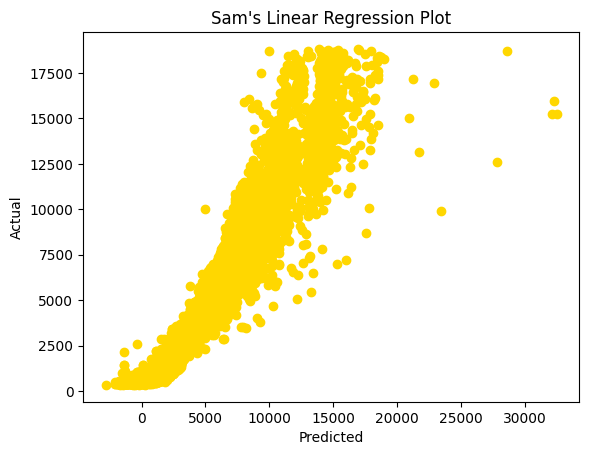

In [51]:
# Plot the regression model with the elements seen
plt.scatter(LR.predict(X_test), y_test, color = "gold")
plt.title("Sam's Linear Regression Plot")
plt.xlabel("Predicted") # The predicted and actual areas are both x and ys here and it shows the relationship in the regression model
plt.ylabel("Actual")
plt.show()

In [52]:
 # Decision Tree Regressor
tree = DecisionTreeRegressor(max_depth=8, random_state=42)  # We have a random seed of 42 again with the max_depth beign at 8 to symbolize the fact that only 80% of the values are being used
tree.fit(X_train, y_train)
y_pred_tree = tree.predict(X_test)
y_pred_tree

array([ 598.33536585, 2227.56565657, 1310.65076336, ...,  696.77739726,
       9889.36666667, 3775.49142857])

In [53]:
# Metrics
def evaluate(y_true, y_pred): # Here we are basially evaluating two points to see the MSRE between them while also checkign their R2 dimension whcih will tell us how much of the value they occupy (R2)
## or how much errors there are in the model considering(MSRE)
    rmse = np.sqrt(mean_squared_error(y_true, y_pred))
    r2 = r2_score(y_true, y_pred)
    return rmse, r2

rmse_lr, r2_lr = evaluate(y_test, y_pred_LR)
rmse_tree, r2_tree = evaluate(y_test, y_pred_tree)

print("Linear Regression:", rmse_lr, r2_lr)
print("Decision Tree:", rmse_tree, r2_tree)


Linear Regression: 1221.7755748638292 0.9060984889393999
Decision Tree: 66.84462549624578 0.9997189246937551


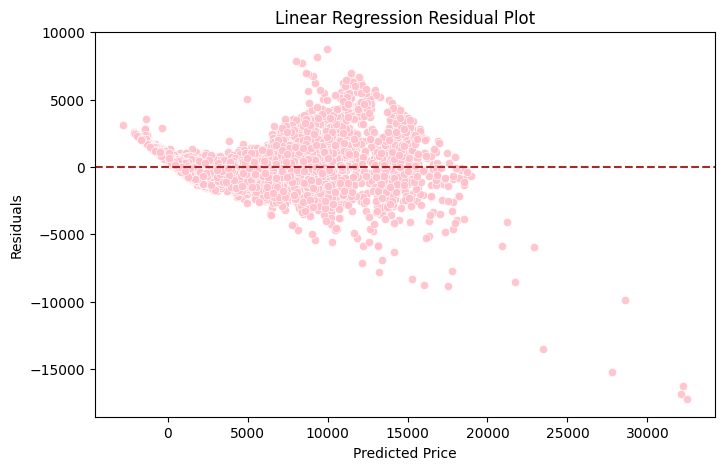

In [54]:
# 6. Residual Plot
residuals = y_test - y_pred_LR

plt.figure(figsize=(8,5))
sns.scatterplot(x=y_pred_LR, y=residuals, alpha=0.9, color="pink")
plt.axhline(0, color='brown', linestyle='--')
plt.xlabel("Predicted Price")
plt.ylabel("Residuals")
plt.title("Linear Regression Residual Plot")
plt.show()

Based on the test‑set diagnostics, the Decision Tree Regressor performs better than the Linear Regression model. The tree achieves lower Root mean square error which definitely leads to more accurate predictions, and a higher R² telling us that it goes over more of the variance in diamond prices than the Linear Regression Model.

When looking at the residual plot for the linear regression model, you can clearly see curves, uneven spread, and some outliers. This tells us the linear model isn’t capturing the nonlinear relationship between features like carat, dimensions, and price. Diamond pricing doesn’t increase in a straight line because small changes in carat can impact the prices differently which makes a linear model bad here.

The decision tree, on the other hand, naturally handles nonlinear patterns and interactions without needing extra transformations. Even though trees can overfit, this one was regularized and still performed better on the test set, which means it’s actually learning the structure of the data instead of memorizing it.


Therefore, the Decision Tree Regressor is the better model for predicting diamond prices.
